# Stock Picker Analysis

**Purpose:** Evaluate stocks against selection criteria to identify potential buy candidates.

**Strategy:** Apply a golden cross filter (MA50 >= MA200) to identify stocks in uptrends.

**Last Updated:** 2026-02-07

## Setup and Configuration

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
from stock_utils import (
    get_stock_data,
    calculate_moving_averages,
    filter_stocks_above_ma,
    plot_stock_ma,
    get_index_constituents,
    print_analysis_summary,
    LOOKBACK_YEARS,
    MA_SHORT,
    MA_LONG,
    SYMBOL_EXCLUDE
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Analysis date: {datetime.now().strftime('%Y-%m-%d')}")

Analysis date: 2026-02-16


In [2]:
# Set today's date as a variable
today = datetime.now()
start_date = today - timedelta(days=LOOKBACK_YEARS * 365)

print(f"Analyzing stocks from {start_date.strftime('%Y-%m-%d')} to {today.strftime('%Y-%m-%d')}")
print(f"Moving averages: MA{MA_SHORT} and MA{MA_LONG}")

Analyzing stocks from 2023-02-17 to 2026-02-16
Moving averages: MA50 and MA200


## 1. Pull Index Constituents

Get the list of stocks from the selected index (DOW, SP500, etc.)

In [28]:
# Select index to analyze
INDEX_NAME = "DOW"  # Options: "DOW", "SP500" (when implemented)

index_info = get_index_constituents(INDEX_NAME)

print(f"\nIndex: {INDEX_NAME}")
print(f"Number of constituents: {len(index_info)}")
print("\nFirst 10 symbols:")
display(index_info.head(10))


Index: DOW
Number of constituents: 31

First 10 symbols:


,symbol,company,identifier,sedol,weight,sector,shares_held,local_currency
0,GS,GOLDMAN SACHS GROUP INC,38141G104,2407966,"0,111999782821409",-,5415350,USD
1,CAT,CATERPILLAR INC,149123101,2180201,"0,0853208902635004",-,5415350,USD
2,MSFT,MICROSOFT CORP,594918104,2588173,"0,0495175882573391",-,5415350,USD
3,HD,HOME DEPOT INC,437076102,2434209,"0,0480962219501226",-,5415350,USD
4,AMGN,AMGEN INC,031162100,2023607,"0,0462635377037046",-,5415350,USD
5,SHW,SHERWIN WILLIAMS CO/THE,824348106,2804211,"0,0454132347441686",-,5415350,USD
6,AXP,AMERICAN EXPRESS CO,025816109,2026082,"0,0446057018135952",-,5415350,USD
7,V,VISA INC CLASS A SHARES,92826C839,B2PZN04,"0,0413994589366441",-,5415350,USD
8,MCD,MCDONALD S CORP,580135101,2550707,"0,0406887707853695",-,5415350,USD
9,JPM,JPMORGAN CHASE + CO,46625H100,2190385,"0,0390133231189029",-,5415350,USD


In [ ]:
# Convert some columns to numeric (clean up any formatting first)
index_info["weight"] = (index_info["weight"]
                        .str.replace(",", ".", regex=False)
                        .replace("", np.nan)
                        .pipe(pd.to_numeric, errors="coerce")
)
print(index_info.info())

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   symbol          31 non-null     str    
 1   company         31 non-null     str    
 2   identifier      31 non-null     str    
 3   sedol           31 non-null     str    
 4   weight          31 non-null     float64
 5   sector          31 non-null     str    
 6   shares_held     31 non-null     str    
 7   local_currency  31 non-null     str    
dtypes: float64(1), str(7)
memory usage: 2.1 KB
None


<Figure size 1200x600 with 0 Axes>

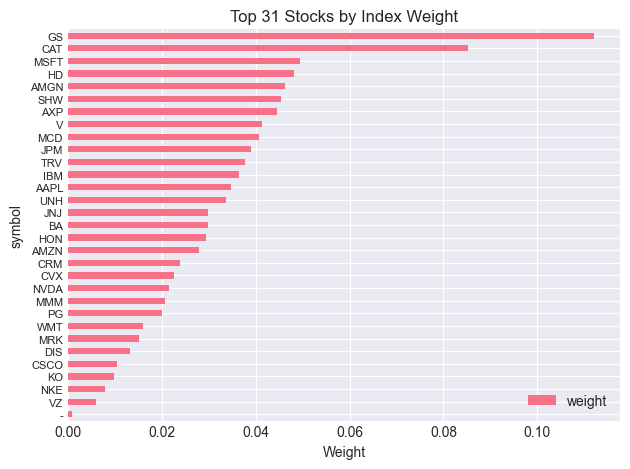

In [49]:
# Plot index weights ordered by weight descending
plt.figure(figsize=(12, 6))
top_n = len(index_info)
index_info.nsmallest(top_n, 'weight').plot(
    x='symbol', 
    y='weight', 
    kind='barh', 
    title=f'Top {top_n} Stocks by Index Weight'
)
plt.xlabel('Weight')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Reference Indices (DJI and VIX)

Check overall market behavior before analyzing individual stocks.

In [50]:
# Fetch DJI and VIX as market reference
reference_symbols = ['^DJI', '^VIX']
df_reference = pd.DataFrame()

for symbol in reference_symbols:
    print(f"Fetching {symbol}...")
    df_temp = get_stock_data(symbol, start_date, today)
    
    if df_temp is not None:
        # Calculate MAs
        df_temp = calculate_moving_averages(df_temp)
        df_reference = pd.concat([df_reference, df_temp], ignore_index=True)

print(f"\nReference data collected: {df_reference['symbol'].unique()}")
print(f"Date range: {df_reference['date'].min()} to {df_reference['date'].max()}")

Fetching ^DJI...
Fetching ^VIX...

Reference data collected: <StringArray>
['^DJI', '^VIX']
Length: 2, dtype: str
Date range: 2023-02-17 00:00:00 to 2026-02-16 00:00:00


In [51]:
# Check for missing data
print(f"Rows before cleaning: {len(df_reference)}")
print(f"Missing 'close' values: {df_reference['close'].isna().sum()}")

# Remove NA values
df_reference = df_reference.dropna(subset=['close'])
print(f"Rows after cleaning: {len(df_reference)}")

Rows before cleaning: 1501
Missing 'close' values: 0
Rows after cleaning: 1501


In [56]:
# Order df by date descending, check max dates for each symbol
df_reference = df_reference.sort_values(by='date', ascending=False)
df_reference.head()

Price,symbol,date,open,high,low,close,volume,adjusted,ma_50,ma_200
1500,^VIX,2026-02-16,20.730000,21.590000,20.370001,21.320000,0,21.320000,16.474600,17.414950
749,^DJI,2026-02-13,49439.578125,49743.980469,49084.351562,49500.929688,597100000,49500.929688,48863.788203,45817.951816
1499,^VIX,2026-02-13,21.480000,22.400000,18.920000,20.600000,0,20.600000,16.369800,17.431850
1498,^VIX,2026-02-12,17.440001,21.209999,17.080000,20.820000,0,20.820000,16.289600,17.449700
748,^DJI,2026-02-12,50170.269531,50447.011719,49420.281250,49451.980469,765340000,49451.980469,48823.258828,45773.085273


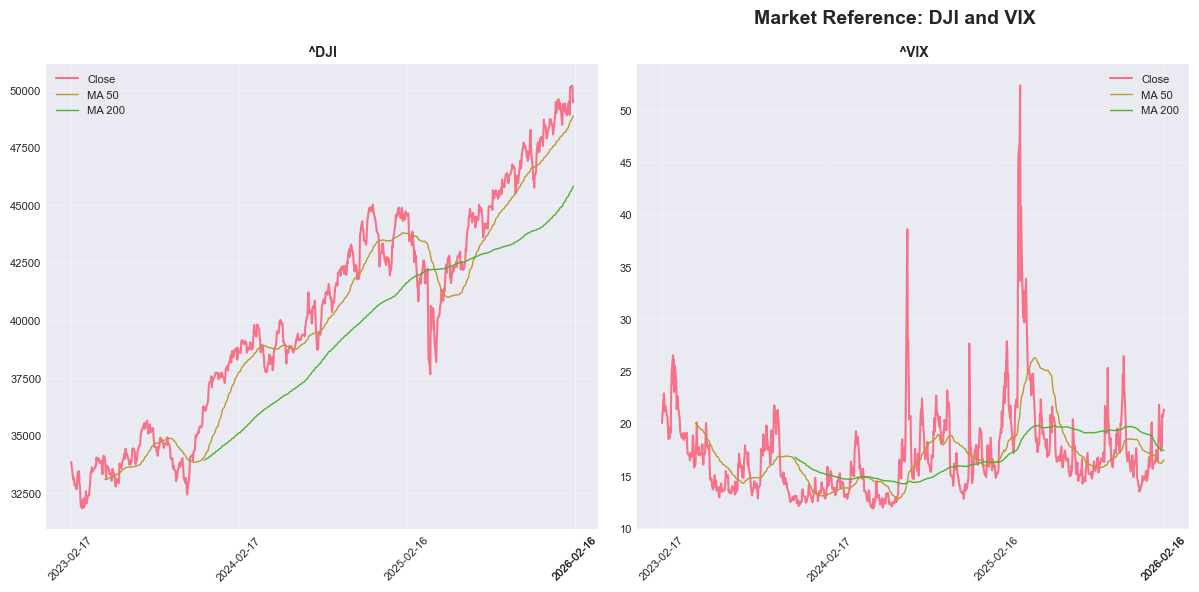


^DJI as of 2026-02-13:
  Close: 49500.93
  MA50:  48863.79
  MA200: 45817.95

^VIX as of 2026-02-16:
  Close: 21.32
  MA50:  16.47
  MA200: 17.41


In [58]:
# Plot reference indices with moving averages
plot_stock_ma(
    df_reference, 
    symbols_to_plot=reference_symbols,
    title="Market Reference: DJI and VIX",
    figsize=(18, 6)
)

# Print latest values
for symbol in reference_symbols:
    latest = df_reference[df_reference['symbol'] == symbol].iloc[0]
    print(f"\n{symbol} as of {latest['date'].strftime('%Y-%m-%d')}:")
    print(f"  Close: {latest['close']:.2f}")
    print(f"  MA50:  {latest['ma_50']:.2f}")
    print(f"  MA200: {latest['ma_200']:.2f}")

## 3. Analyze Individual Stocks

Loop through each stock in the index and apply the selection criteria (MA50 >= MA200).

In [ ]:
# Initialize storage for results
df_all_stocks = pd.DataFrame()  # All historical data for passing stocks
df_results = pd.DataFrame()     # Summary: one row per passing stock
warning_symbols = []

# Loop through each symbol
symbols_to_analyze = index_info['symbol'].unique()

for i, symbol in enumerate(symbols_to_analyze, 1):
    print(f"\rProcessing {i}/{len(symbols_to_analyze)}: {symbol}", end="")
    
    # Fetch stock data
    df = get_stock_data(symbol, start_date, today)
    
    if df is None:
        warning_symbols.append(symbol)
        continue
    
    # Calculate moving averages
    df = calculate_moving_averages(df)
    
    # Check if stock passes criteria (MA50 >= MA200 on most recent date)
    latest = df.iloc[-1]
    if latest['ma_50'] >= latest['ma_200']:
        # Store full history for plotting
        df_all_stocks = pd.concat([df_all_stocks, df], ignore_index=True)
        
        # Store summary row
        df_results = pd.concat([df_results, latest.to_frame().T], ignore_index=True)

print("\n\nData collection complete!")

In [ ]:
# Exclude specific symbols (based on manual review)
print(f"Symbols before exclusion: {len(df_results)}")

if not df_results.empty:
    df_results = df_results[~df_results['symbol'].isin(SYMBOL_EXCLUDE)]
    df_all_stocks = df_all_stocks[~df_all_stocks['symbol'].isin(SYMBOL_EXCLUDE)]

print(f"Symbols after exclusion: {len(df_results)}")
print(f"Excluded: {SYMBOL_EXCLUDE}")

In [ ]:
# Print analysis summary
print_analysis_summary(df_results, len(symbols_to_analyze), len(warning_symbols))

## 4. Visualize Results

Plot all stocks that passed the selection criteria.

In [ ]:
# Display summary table
if not df_results.empty:
    display_cols = ['symbol', 'date', 'close', 'ma_50', 'ma_200']
    print("\nStocks passing MA50 >= MA200 criteria:")
    display(df_results[display_cols].sort_values('symbol'))
else:
    print("No stocks passed the criteria.")

In [ ]:
# Plot all passing stocks
if not df_results.empty:
    passing_symbols = df_results['symbol'].unique()
    
    plot_stock_ma(
        df_all_stocks,
        symbols_to_plot=passing_symbols,
        title=f"Stocks Above MA{MA_LONG} ({INDEX_NAME} Index)",
        figsize=(16, 12)
    )
else:
    print("No stocks to plot.")

## 5. Interactive Selection (Optional)

Create an interactive widget to select specific stocks to plot.

In [ ]:
# Optional: Interactive plotting with ipywidgets
# Uncomment to use:

# from ipywidgets import interactive, SelectMultiple
# from IPython.display import display

# if not df_results.empty:
#     def plot_selected(symbols):
#         if symbols:
#             plot_stock_ma(df_all_stocks, list(symbols), "Selected Stocks")
#     
#     widget = interactive(
#         plot_selected,
#         symbols=SelectMultiple(
#             options=sorted(df_results['symbol'].unique()),
#             value=sorted(df_results['symbol'].unique())[:5],
#             description='Stocks:'
#         )
#     )
#     display(widget)

## 6. Export Results

In [ ]:
# Optional: Save results to CSV
if not df_results.empty:
    output_file = f"stock_analysis_{today.strftime('%Y%m%d')}.csv"
    df_results[['symbol', 'date', 'close', 'ma_50', 'ma_200']].to_csv(output_file, index=False)
    print(f"Results saved to: {output_file}")

## Analysis Notes

**Update Log:**
- 2026-02-01: 20 stocks above dc. BA, UNH in. MSFT out. DJI down 48892, VIX up 17.
- [Add your observations here after each analysis run]

**Market Context:**
- Track major events (Fed decisions, geopolitical events, policy changes)
- Note significant market moves
- Document stock additions/removals from passing list